In [41]:
from jax import config
config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp
import jaxopt
from jax.nn import softplus

import matplotlib.pyplot as plt
from tqdm import tqdm 

import utils
import mappings
import noise_models
from core import GPLVM, DynamicGPLVM, Layer, Proposal
from mc_samplers import Roberts

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import sys
sys.path.append('/mnt/home/igaron/gplvm')

# Unsupervised - Static - ULA and LBFGS

### Simulate

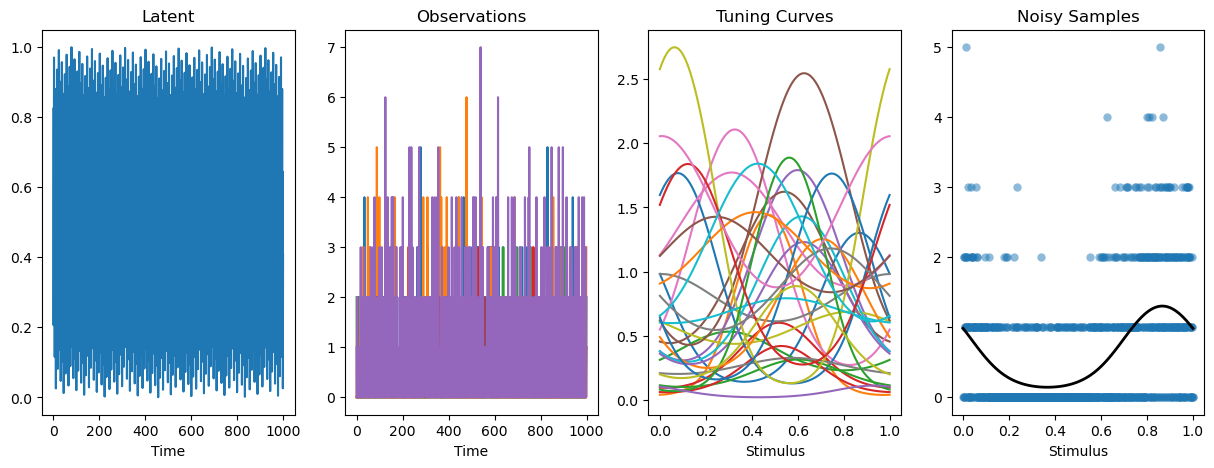

In [43]:
# Simulation params
num_neurons = 30
num_dims = 1
num_steps = 1000

# Tuning prior
basis_params = {
                "max_freq": 30, 
                "num_dims": num_dims, 
                "out_scale":10., 
                "len_scale":.6,
                "bias_mean": 0,
                "bias_std": 0,
                "num_neurons":num_neurons,
                "tol":1e-4,
                "nonlinearity":lambda x: softplus(x),
                }

# KEY DUMP
GEN_KEY = jax.random.PRNGKey(17)
INIT_KEY = jax.random.PRNGKey(25)
OPT_KEY = jax.random.PRNGKey(123)
IS_KEY = jax.random.PRNGKey(7)

# Construct model
model = GPLVM(observation=Layer(
                mapping=mappings.WeightedFourierBasisMapping(basis_params),
                noise=noise_models.Poisson(),
            ),
            sampler = Roberts(num_dims, mc_scale=1))

params_per_neuron = model.observation.mapping.params_per_neuron

# Sample true parameters of model
true_weights = jax.random.normal(
                        GEN_KEY, 
                        shape=(params_per_neuron, num_neurons)
                    )
# TODO - alternatively sample from observation model, idk
# model.observation.mapping.sample(jax.random.PRNGKey(999), JUNKJUNK)


# Generate data
xs_true, ys = model.simulate(
    key=GEN_KEY,
    params=true_weights,
    num_observations=num_steps
)

utils.plot_simulated_data_1D(xs_true, true_weights, ys, model);


### Fit - LBFGS

100%|████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 47.97it/s]


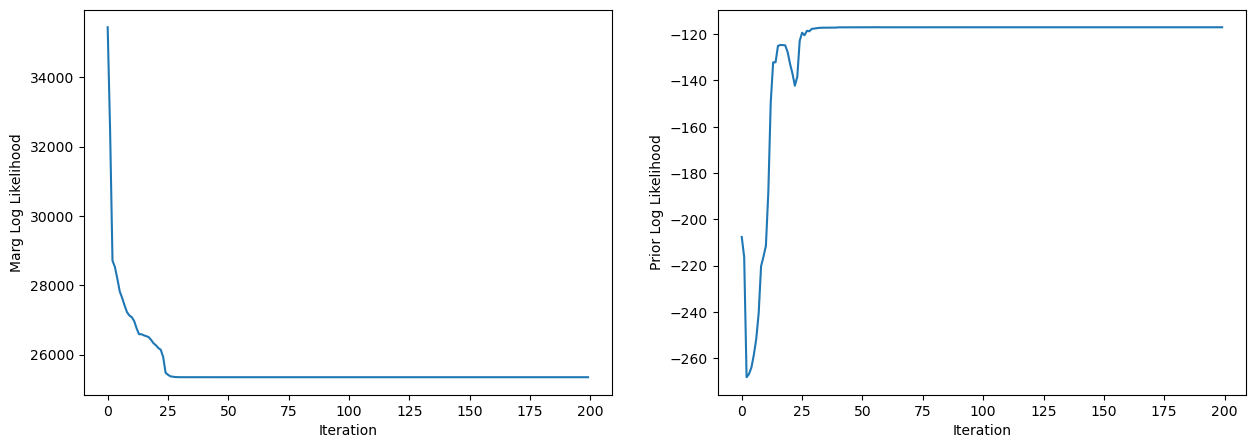

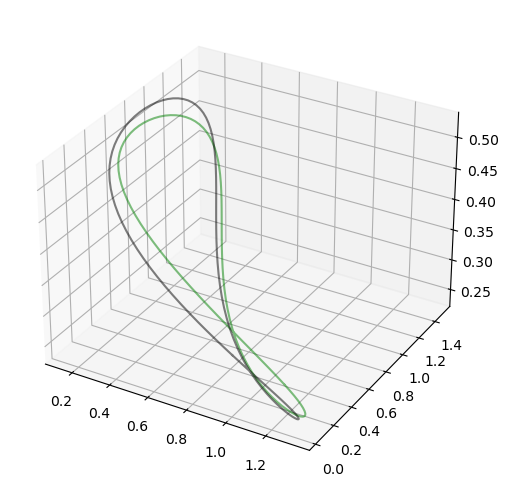

In [44]:
est_params = jax.random.normal(
                        INIT_KEY, 
                        shape=(params_per_neuron, num_neurons)
                    )
# TODO - play with initializing in inference class?

opt_params = {
    "init_params":est_params,
    "save_prior":True,
    "opt_key": OPT_KEY,
    "init_key": INIT_KEY,
    "n_iters":  200
}

model.fit(ys, "lbfgs", opt_params)
    
utils.plot_objhist(model);
utils.plot_3d_neurons(model, true_weights, grid_reso = 100, neurs = [0,1,2]);


### Fit - ULA

In [45]:


est_params = jax.random.normal(
                        INIT_KEY, 
                        shape=(12, params_per_neuron, num_neurons)
                    )
opt_params = {
    "init_params":est_params,
    "opt_key":OPT_KEY,
    "init_key":INIT_KEY,
    "is_key":IS_KEY,
    "n_iters": 10000,
    "n_chains": 12,
    "friction":0.1,
    "min_lr": 1e-6,
    "max_lr": 1e-5,
    "noise_multiplier":1.,
    "burn_in":2000,
    "save_every":250,
    "params_per_neuron":params_per_neuron,
    "num_neurons":num_neurons
}

model.fit(ys, "ula", opt_params)
    
plt.figure()
model.objhist_ = jnp.array(model.objhist_)
plt.plot(model.objhist_)
plt.axhline(model.log_posterior_params(true_weights, ys, jax.random.PRNGKey(0)), dashes=[2, 2], color='k')
plt.ylim(jnp.max(model.objhist_) + jnp.max(model.objhist_)/100, jnp.max(model.objhist_)-jnp.max(model.objhist_)/100)
fig = plt.figure()
fig, ax2 = plt.subplots(1, 1, sharex=True, sharey=True)
fig = plt.figure()
ax1 = fig.add_subplot(projection='3d')

true_tunings = model.observation.mapping(true_weights, x_grid)
ax1.plot(true_tunings[:,0], true_tunings[:,1], true_tunings[:,2], c='k', alpha=.25)
ax2.plot(true_tunings[:,:3], c='k', alpha=.5)

chain_ind=5
for i in range(10):
    for j in range(3):
        curr_param = model.saved_params_[i][chain_ind,:,:]
        est_tunings = model.observation.mapping(curr_param, x_grid)
        ax1.plot(est_tunings[:,0], est_tunings[:,1], est_tunings[:,2], c='green', alpha=.25)
        ax2.plot(est_tunings[:,:3], c='green', alpha=.5)



  0%|                                                                            | 0/10000 [00:00<?, ?it/s]

# EIV - Static - ULA and LBFGS

### Simulate

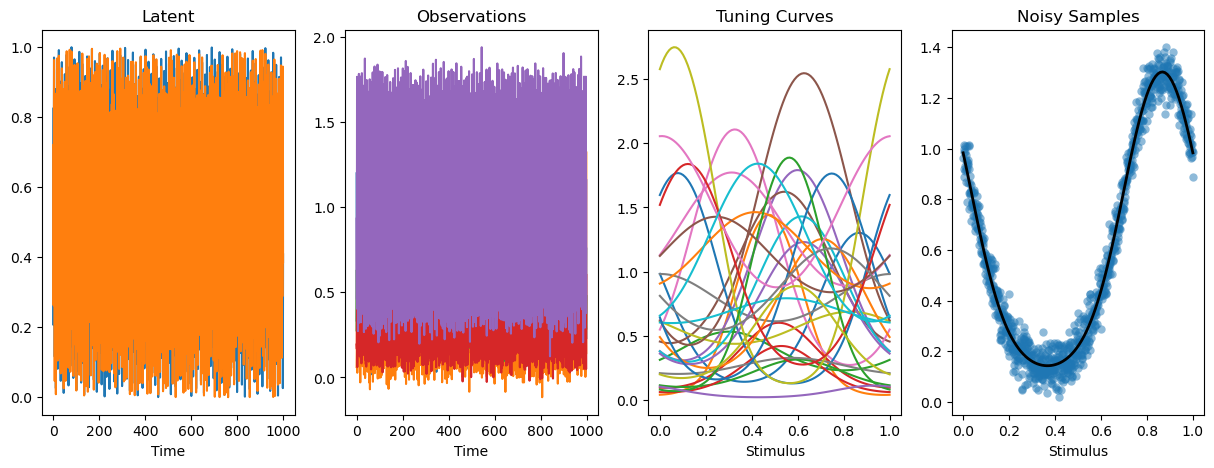

In [ ]:
num_neurons = 30
num_dims = 1
num_steps = 1000

basis_params = {
                "max_freq": 30, 
                "num_dims": num_dims, 
                "out_scale":10., 
                "len_scale":.8,
                "bias_mean": 0,
                "bias_std": 0,
                "num_neurons":num_neurons,
                "tol":1e-4,
                "nonlinearity":lambda x: softplus(x),
                }

# TODO - Latent space must norm to 1, unit check noise models
# TODO - Could use a better data struct to organize these params
model = GPLVM(
    observation=Layer(
        mapping=[mappings.WeightedFourierBasisMapping(basis_params),
                                        mappings.IdentityMapping()],
        noise=[noise_models.Gaussian(.05),noise_models.ProjectedNormalNormed(5.)], 
    ),
    sampler = Roberts(num_dims, mc_scale=1))

params_per_neuron = model.observation.mapping.mappings[0].params_per_neuron

# Sample true parameters of model
true_weights = jax.random.normal(
                        GEN_KEY, shape=(params_per_neuron, num_neurons)
                    )

xs_true, ys = model.simulate(
    key=GEN_KEY,
    params=true_weights,
    num_observations=num_steps
)

utils.plot_simulated_data_1D(xs_true, true_weights, ys, model);


### Fit - LBFGS

100%|████████████████████████████████████████████████████████████████████| 500/500 [00:06<00:00, 73.15it/s]


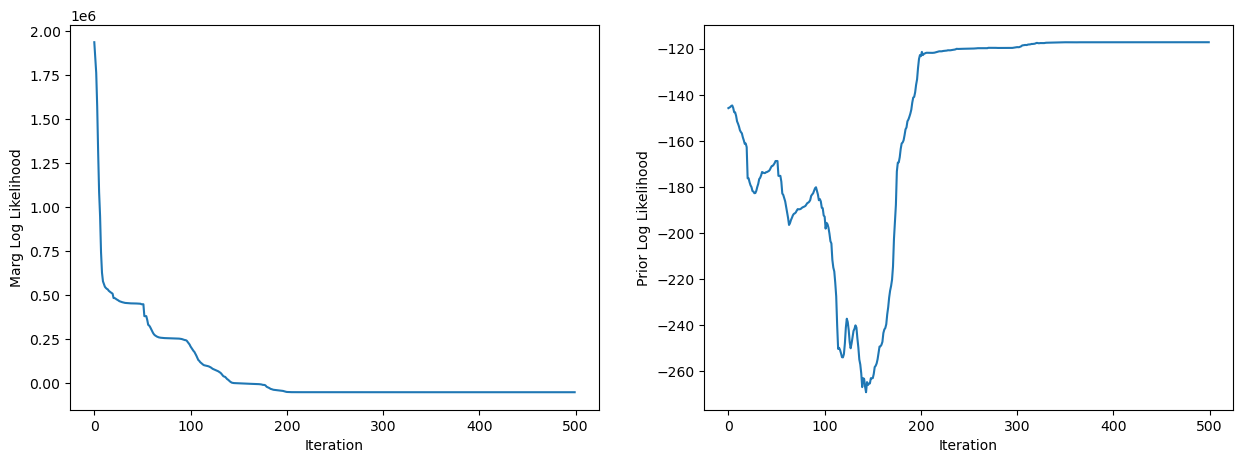

True


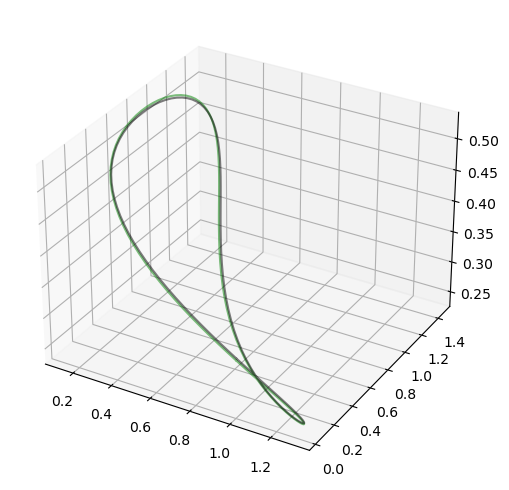

In [ ]:
est_params = jax.random.normal(
                        INIT_KEY, 
                        shape=(params_per_neuron, num_neurons)
                    )

opt_params = {
    "init_params":est_params,
    "save_prior":True,
    "opt_key":OPT_KEY,
    "init_key":INIT_KEY,
    "n_iters": 500
}

model.fit(ys, "lbfgs", opt_params)
    
utils.plot_objhist(model);
utils.plot_3d_neurons(model, true_weights, grid_reso = 100, neurs = [0,1,2]);


### Fit - ULA

 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...


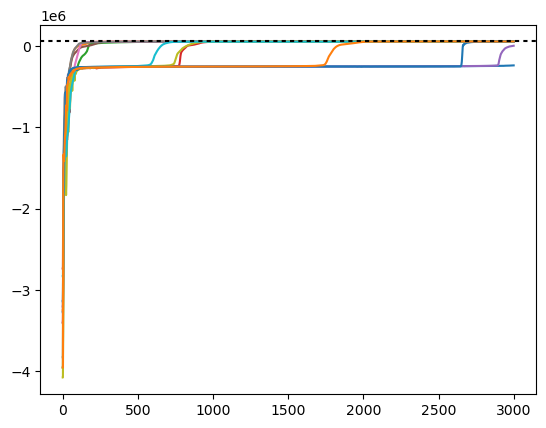

<Figure size 640x480 with 0 Axes>

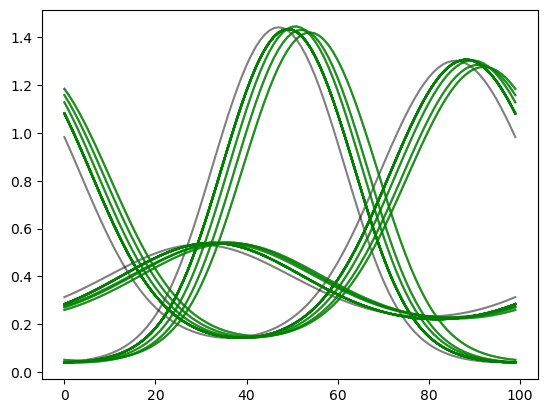

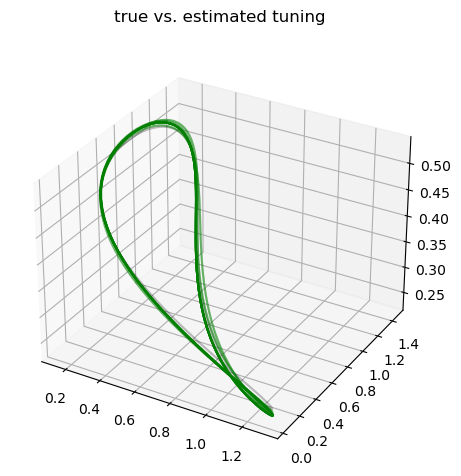

In [ ]:

est_params = jax.random.normal(
                        INIT_KEY, 
                        shape=(12, params_per_neuron, num_neurons)
                    )
opt_params = {
    "init_params":est_params,
    "opt_key":OPT_KEY,
    "init_key":INIT_KEY,
    "is_key":IS_KEY,
    "n_iters": 3000,
    "n_chains": 12,
    "friction":0.2,
    "min_lr": 1e-7,
    "max_lr": 1e-6,
    "noise_multiplier":3.,
    "burn_in":500,
    "save_every":500,
    "params_per_neuron":params_per_neuron,
    "num_neurons":num_neurons
}

model.fit(ys, "ula", opt_params)
    
plt.figure()
model.objhist_ = jnp.array(model.objhist_)
plt.plot(model.objhist_)
plt.axhline(model.log_posterior_params(true_weights, ys, jax.random.PRNGKey(0)), dashes=[2, 2], color='k')
#plt.ylim(jnp.max(model.objhist_) + jnp.max(model.objhist_)/100, jnp.max(model.objhist_)-jnp.max(model.objhist_)/100)
fig = plt.figure()
fig, ax2 = plt.subplots(1, 1, sharex=True, sharey=True)
fig = plt.figure()
ax1 = fig.add_subplot(projection='3d')

true_tunings = model.observation.mapping(true_weights, x_grid)[0]
ax1.plot(true_tunings[:,0], true_tunings[:,1], true_tunings[:,2], c='k', alpha=.25)
ax2.plot(true_tunings[:,:3], c='k', alpha=.5)

rank_order_chains = jnp.argsort(jnp.mean(model.objhist_[2000:], axis=0))[::-1]
chain_ind=rank_order_chains[0]
for i in range(10):
    for j in range(3):
        curr_param = model.saved_params_[i][chain_ind,:,:]
        est_tunings = model.observation.mapping(curr_param, x_grid)[0]
        ax1.plot(est_tunings[:,0], est_tunings[:,1], est_tunings[:,2], c='green', alpha=.25)
        ax2.plot(est_tunings[:,:3], c='green', alpha=.5)

for j in range(10):
    curr_param = model.saved_params_[j][chain_ind,:,:]
    est_tunings = model.observation.mapping(curr_param, x_grid)[0]
    for i, ax in enumerate(axes.ravel()):
        ax.plot(true_tunings[:,i], color="k", alpha=.8, label="true")
        ax.plot(est_tunings[:,i], color="g", alpha=.8, dashes=[2, 2], label="est")
    #axes[-1, -1].legend()
    fig.suptitle("true vs. estimated tuning")
    fig.tight_layout()

# Unsupervised - DYNAMIC - ULA and LBFGS

### Simulate

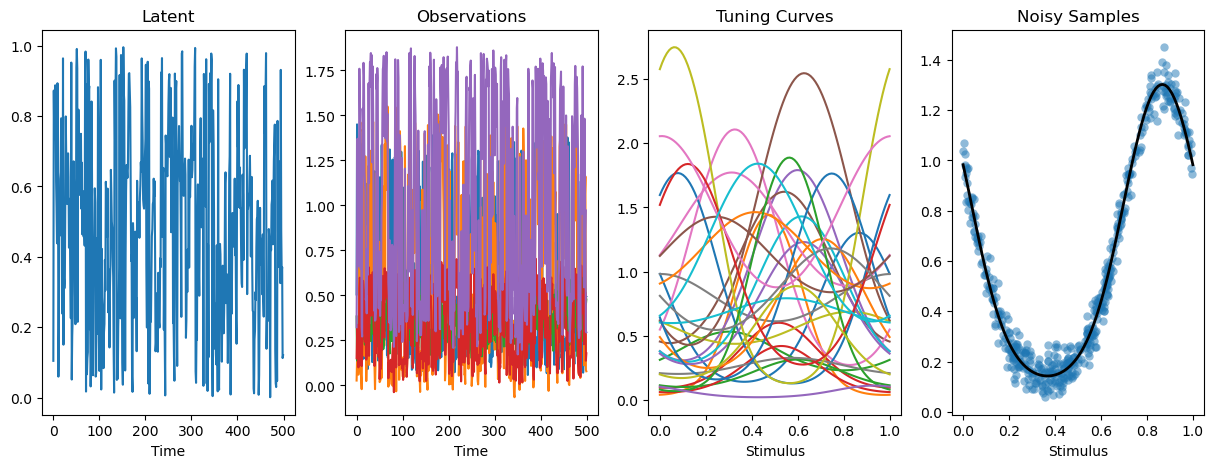

In [ ]:
num_neurons = 30
num_dims = 1
num_particles = 100
num_timesteps = 500

basis_params = {
                "max_freq": 30, 
                "num_dims": num_dims, 
                "out_scale":20., 
                "len_scale":.8,
                "bias_mean": 0,
                "bias_std": 0,
                "num_neurons":num_neurons,
                "tol":1e-4,
                "nonlinearity":lambda x: softplus(x),
                }

# TODO - param org is bad here.
proposal = Proposal(
    layer=Layer(
        mapping=mappings.identity,
        noise=noise_models.ProjectedNormalNormed(1.)
    ),
    params= jnp.array(1.),
    init_params=jnp.array(1.),
    init_loc = jnp.zeros(num_dims)                   
)


model = DynamicGPLVM(
    transition=Layer(
        mapping=mappings.identity,
        noise=noise_models.ProjectedNormalNormed(1.)
    ),
    observation= Layer(
        mapping=[mappings.WeightedFourierBasisMapping(basis_params)],
        noise=[noise_models.Gaussian(.05)],
    ),
    num_samples = num_particles,
    proposal = proposal, 
)

params_per_neuron = model.observation.mapping.mappings[0].params_per_neuron
 
true_weights = jax.random.normal(
                        GEN_KEY, 
                        shape=(params_per_neuron, num_neurons)
                    )

xs_true, ys = model.simulate(
    key=GEN_KEY,
    params=true_weights,
    x_init=jnp.zeros(num_dims), 
    num_timesteps=num_timesteps # for static, this is an array of values
)

utils.plot_simulated_data_1D(xs_true, true_weights, ys, model);



100%|████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 44.17it/s]


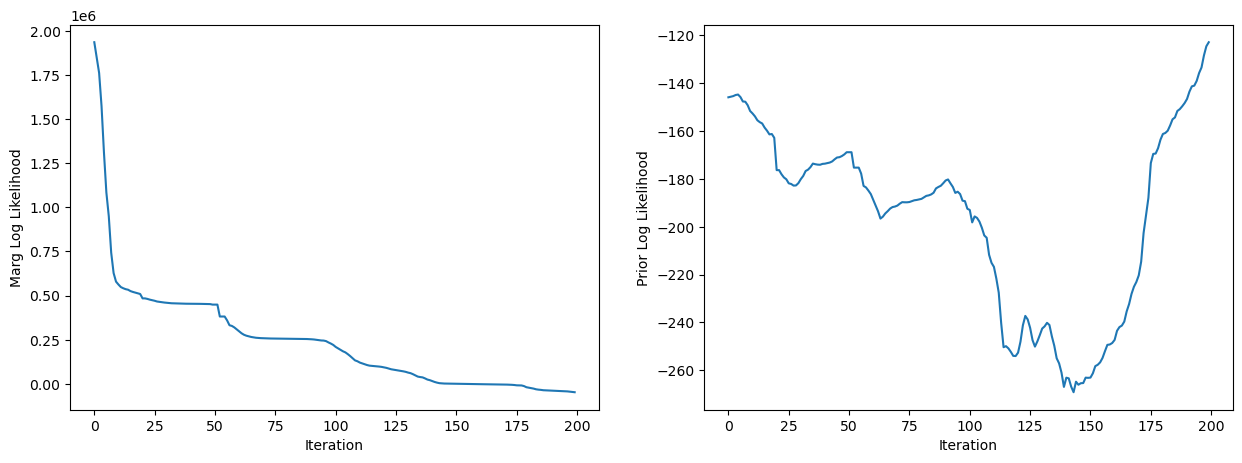

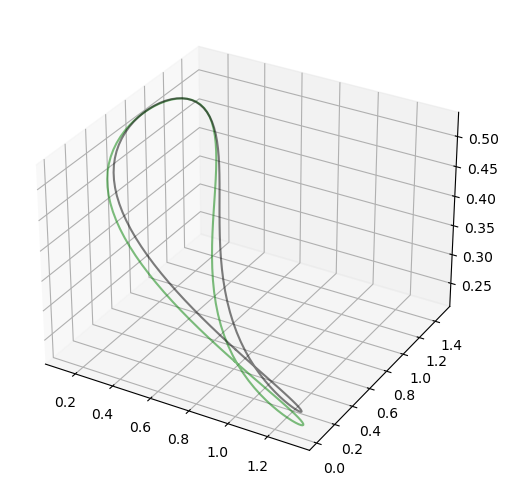

In [ ]:
est_params = jax.random.normal(
                        INIT_KEY, 
                        shape=(params_per_neuron, num_neurons)
                    )

opt_params = {
    "init_params":est_params,
    "save_prior":True,
    "opt_key":OPT_KEY,
    "init_key":INIT_KEY,
    "n_iters":  200
}

model.fit(ys, "lbfgs", opt_params)
    
utils.plot_objhist(model);
utils.plot_3d_neurons(model, true_weights, grid_reso = 100, neurs = [0,1,2]);


 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...


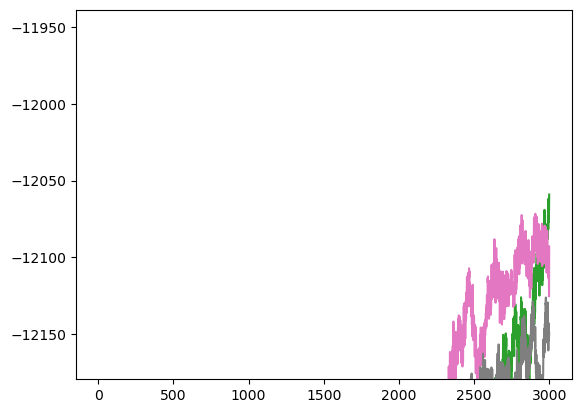

<Figure size 640x480 with 0 Axes>

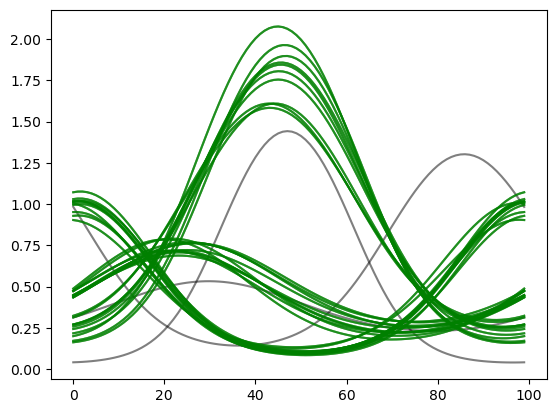

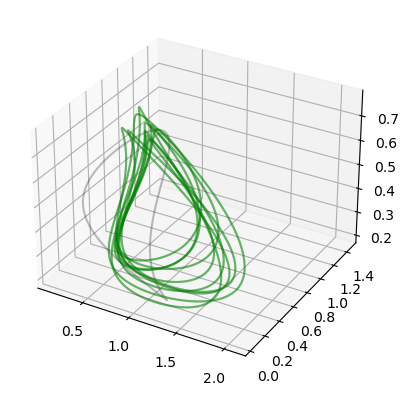

In [ ]:

est_params = jax.random.normal(
                        INIT_KEY, 
                        shape=(12, params_per_neuron, num_neurons)
                    )
opt_params = {
    "init_params":est_params,
    "opt_key":OPT_KEY,
    "init_key":INIT_KEY,
    "is_key":IS_KEY,
    "n_iters": 3000,
    "n_chains": 12,
    "friction":0.5,
    "min_lr": 1e-6,
    "max_lr": 1e-5,
    "noise_multiplier":2.,
    "burn_in":1000,
    "save_every":100,
    "params_per_neuron":params_per_neuron,
    "num_neurons":num_neurons
}

model.fit(ys, "ula", opt_params)
    
plt.figure()
model.objhist_ = jnp.array(model.objhist_)
plt.plot(model.objhist_)
plt.axhline(model.log_posterior_params(true_weights, ys, jax.random.PRNGKey(0)), dashes=[2, 2], color='k')
plt.ylim(jnp.max(model.objhist_) + jnp.max(model.objhist_)/100, jnp.max(model.objhist_)-jnp.max(model.objhist_)/100)
fig = plt.figure()
fig, ax2 = plt.subplots(1, 1, sharex=True, sharey=True)
fig = plt.figure()
ax1 = fig.add_subplot(projection='3d')

true_tunings = model.observation.mapping(true_weights, x_grid)[0]
ax1.plot(true_tunings[:,0], true_tunings[:,1], true_tunings[:,2], c='k', alpha=.25)
ax2.plot(true_tunings[:,:3], c='k', alpha=.5)

chain_ind=5
for i in range(10):
    for j in range(3):
        curr_param = model.saved_params_[i][chain_ind,:,:]
        est_tunings = model.observation.mapping(curr_param, x_grid)[0]
        ax1.plot(est_tunings[:,0], est_tunings[:,1], est_tunings[:,2], c='green', alpha=.25)
        ax2.plot(est_tunings[:,:3], c='green', alpha=.5)



# EIV - DYNAMIC - ULA and LBFGS (in progress)

### Simulate

[<mappings.WeightedFourierBasisMapping object at 0x1554a05ace50>, <mappings.IdentityMapping object at 0x154e17c708d0>]


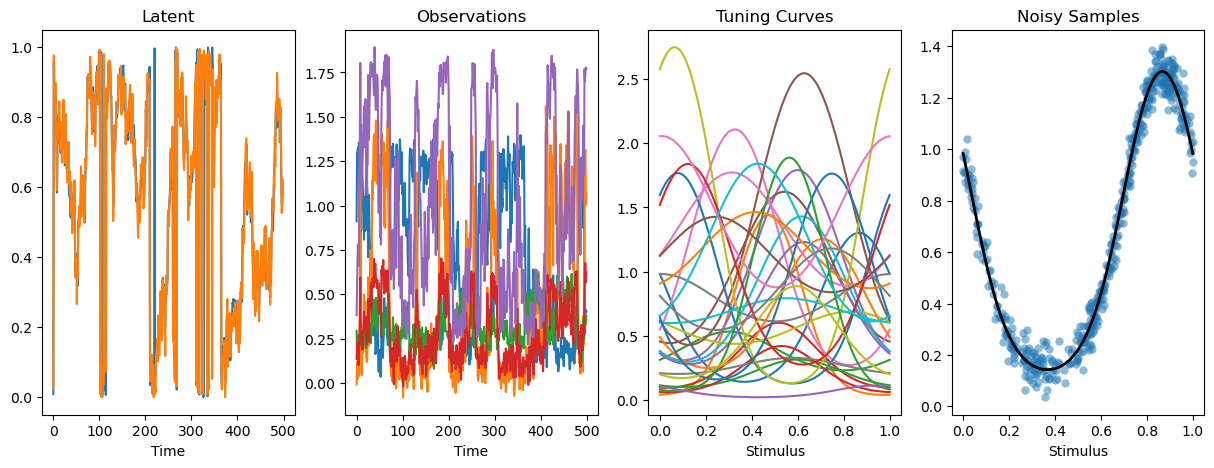

In [ ]:
proposal = Proposal(
    layer=Layer(
        mapping=mappings.identity,
        noise=noise_models.ProjectedNormalNormed(5.)
    ),
    params= jnp.array(5.),
    init_params=jnp.array(5.),
    init_loc = jnp.zeros(num_dims)                   
)

model = DynamicGPLVM(
    transition=Layer(
        mapping=mappings.identity,
        noise=noise_models.ProjectedNormalNormed(3.)
    ),
    observation= Layer(
        mapping=[mappings.WeightedFourierBasisMapping(basis_params),
                                        mappings.IdentityMapping()],
        noise=[noise_models.Gaussian(.05),noise_models.ProjectedNormalNormed(5.)]
    ),num_samples = num_particles,
    proposal = proposal, 
)

params_per_neuron = model.observation.mapping.mappings[0].params_per_neuron

true_weights = jax.random.normal(
                        GEN_KEY, 
                        shape=(params_per_neuron, num_neurons)
                    )

xs_true, ys = model.simulate(
    key=GEN_KEY,
    params=true_weights,
    x_init=jnp.zeros(num_dims), 
    num_timesteps=num_timesteps # for static, this is an array of values
)

utils.plot_simulated_data_1D(xs_true, true_weights, ys, model);


100%|████████████████████████████████████████████████████████████████████| 200/200 [00:06<00:00, 31.63it/s]


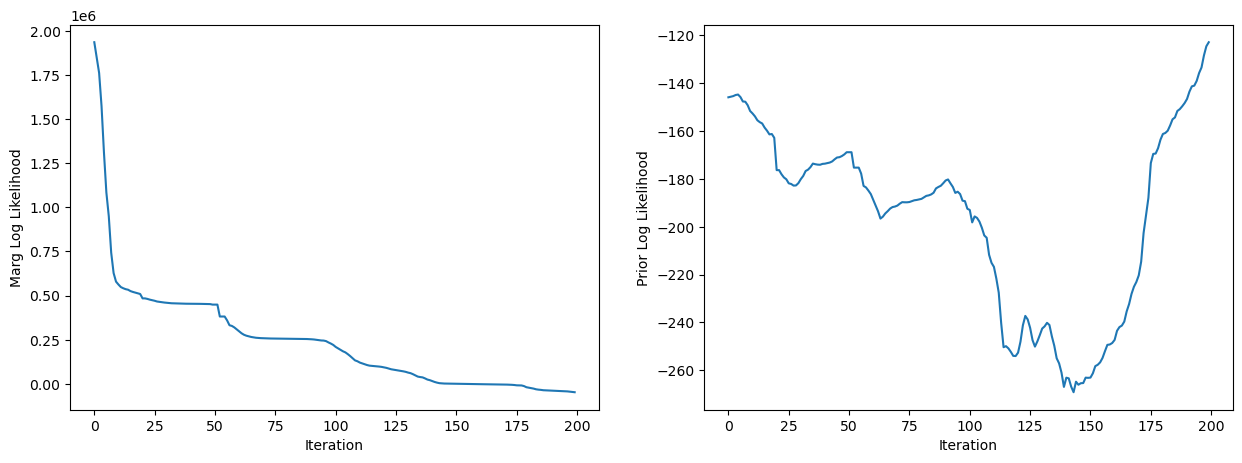

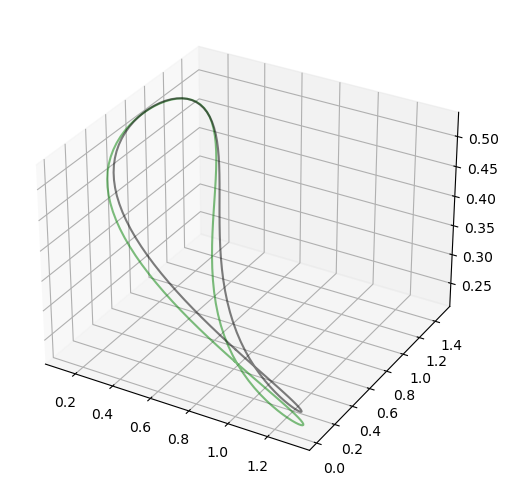

In [ ]:
est_params = jax.random.normal(
                        INIT_KEY, 
                        shape=(params_per_neuron, num_neurons)
                    )

opt_params = {
    "init_params":est_params,
    "save_prior":True,
    "opt_key":OPT_KEY,
    "init_key":INIT_KEY,
    "n_iters":  200
}

model.fit(ys, "lbfgs", opt_params)
    
utils.plot_objhist(model);
utils.plot_3d_neurons(model, true_weights, grid_reso = 100, neurs = [0,1,2]);


 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...


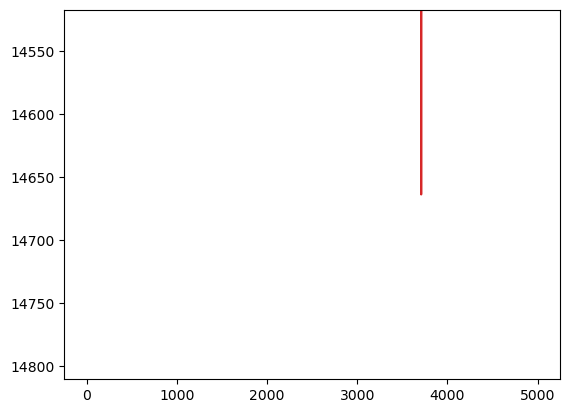

<Figure size 640x480 with 0 Axes>

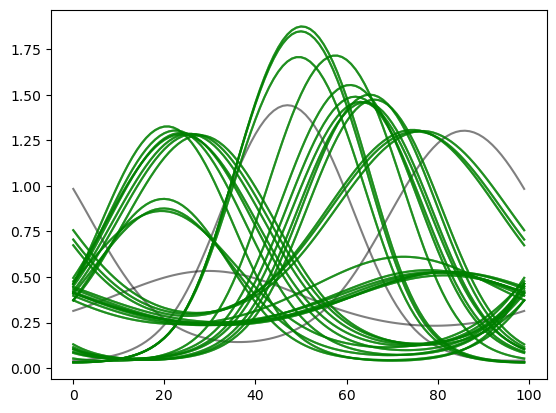

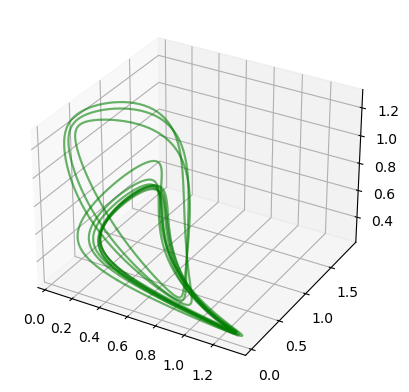

In [ ]:
est_params = jax.random.normal(
                        INIT_KEY, 
                        shape=(12, params_per_neuron, num_neurons)
                    )

opt_params = {
    "init_params":est_params,
    "opt_key":OPT_KEY,
    "init_key":INIT_KEY,
    "is_key":IS_KEY,
    "n_iters": 5000,
    "n_chains": 12,
    "friction":0.3,
    "min_lr": 1e-7,
    "max_lr": 1e-6,
    "noise_multiplier":2.,
    "burn_in":1000,
    "save_every":250,
    "params_per_neuron":params_per_neuron,
    "num_neurons":num_neurons
}


model.fit(ys, "ula", opt_params)
    
plt.figure()
model.objhist_ = jnp.array(model.objhist_)
plt.plot(model.objhist_)
plt.axhline(model.log_posterior_params(true_weights, ys, jax.random.PRNGKey(0)), dashes=[2, 2], color='k')
plt.ylim(jnp.max(model.objhist_) + jnp.max(model.objhist_)/100, jnp.max(model.objhist_)-jnp.max(model.objhist_)/100)
fig = plt.figure()
fig, ax2 = plt.subplots(1, 1, sharex=True, sharey=True)
fig = plt.figure()
ax1 = fig.add_subplot(projection='3d')

true_tunings = model.observation.mapping(true_weights, x_grid)[0]
ax1.plot(true_tunings[:,0], true_tunings[:,1], true_tunings[:,2], c='k', alpha=.25)
ax2.plot(true_tunings[:,:3], c='k', alpha=.5)

chain_ind=5
for i in range(10):
    for j in range(3):
        curr_param = model.saved_params_[i][chain_ind,:,:]
        est_tunings = model.observation.mapping(curr_param, x_grid)[0]
        ax1.plot(est_tunings[:,0], est_tunings[:,1], est_tunings[:,2], c='green', alpha=.25)
        ax2.plot(jnp.flip(est_tunings[:,:3]), c='green', alpha=.5)
